In [35]:
import pandas as pd
import os
from IPython.display import display
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

INPUT_A_PATH = r'E:\E-Data\Projects\Clients\ITD\IdahoSTDM\Tasks\Model Updates\Old Model Run\Model2010\inputs_2010\PopSyn'
INPUT_B_PATH = r'E:\E-Data\Projects\Clients\ITD\IdahoSTDM\Models\BaseYear\Development\ITDSTDM_jls2\inputs2020\PopSyn'


county_a = pd.read_csv(os.path.join(INPUT_A_PATH, "countyData.csv")).set_index('CNTYIDFP00')
county_b = pd.read_csv(os.path.join(INPUT_B_PATH, "countyData.csv")).set_index('CNTYIDFP00')

tot_per_a = county_a[['AGE1', 'AGE2', 'AGE3', 'AGE4', 'AGE5', 'AGE6', 'AGE7', 'AGE8', 'AGE9', 'AGE10', 'AGE11', 'AGE12']].sum().sum()
tot_per_b = county_b[['AGE1', 'AGE2', 'AGE3', 'AGE4', 'AGE5', 'AGE6', 'AGE7', 'AGE8', 'AGE9', 'AGE10', 'AGE11', 'AGE12']].sum().sum()

tot_emp_a = county_a[['OCCP1', 'OCCP2', 'OCCP3', 'OCCP4', 'OCCP5', 'OCCP6', 'OCCP7', 'OCCP8', 'OCCP9']].sum().sum()
tot_emp_b = county_b[['OCCP1', 'OCCP2', 'OCCP3', 'OCCP4', 'OCCP5', 'OCCP6', 'OCCP7', 'OCCP8', 'OCCP9']].sum().sum()

print(f"The total population in a: {tot_per_a:,.0f}, in b: {tot_per_b:,.0f}")
print(f"The total occp in a: {tot_emp_a:,.0f}, in b: {tot_emp_b:,.0f}")


The total population in a: 2,944,752, in b: 3,585,578
The total occp in a: 2,944,753, in b: 3,585,578


In [36]:
county_a

,CTYPOP,AGE1,AGE2,AGE3,AGE4,AGE5,AGE6,AGE7,AGE8,AGE9,...,AGE12,OCCP1,OCCP2,OCCP3,OCCP4,OCCP5,OCCP6,OCCP7,OCCP8,OCCP9
CNTYIDFP00,,,,,,,,,,,,,,,,,,,,,
16001,187507,19213,26590,9370,5119,10848,25066,29176,24744,19525,...,1996,15866,20806,664,3085,3413,5199,17159,19714,101601
16003,7082,588,738,367,235,521,784,842,999,930,...,115,357,462,8,117,61,188,613,1206,4070
16005,19010,2113,2099,796,622,1791,2543,2144,2437,2124,...,240,979,1535,123,259,282,480,1814,3117,10421
16007,17398,1934,1921,729,569,1639,2327,1962,2231,1944,...,219,896,1405,112,237,258,439,1661,2853,9537
16009,21333,1778,2045,1018,637,1586,2365,2623,3132,2988,...,314,1231,1800,20,244,356,599,2135,2937,12010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53051,174556,15309,19485,9069,6178,13126,18720,20574,24188,23010,...,2598,8998,11941,296,3293,1978,3304,13414,26849,104483
53063,199161,16836,18347,7438,4873,22569,29540,25525,26026,22905,...,3645,10614,21765,1418,2811,3527,5221,26136,21249,106420
53075,88103,6394,7286,3221,2748,11592,10972,9301,11889,11134,...,2071,5755,8952,1941,1368,1698,2023,8839,10712,46814


# Overall Age Group Population

C:\Users\james.sullivan\AppData\Local\Temp\36\ipykernel_62556\1031431668.py:1: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df = pd.DataFrame({'scen_a': county_a[['AGE1', 'AGE2', 'AGE3', 'AGE4', 'AGE5', 'AGE6', 'AGE7', 'AGE8', 'AGE9', 'AGE10', 'AGE11', 'AGE12']].sum(0),
C:\Users\james.sullivan\AppData\Local\Temp\36\ipykernel_62556\1031431668.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  'scen_b': county_b[['AGE1', 'AGE2', 'AGE3', 'AGE4', 'AGE5', 'AGE6', 'AGE7', 'AGE8', 'AGE9', 'AGE10', 'AGE11', 'AGE12']].sum(0)}).reset_index()


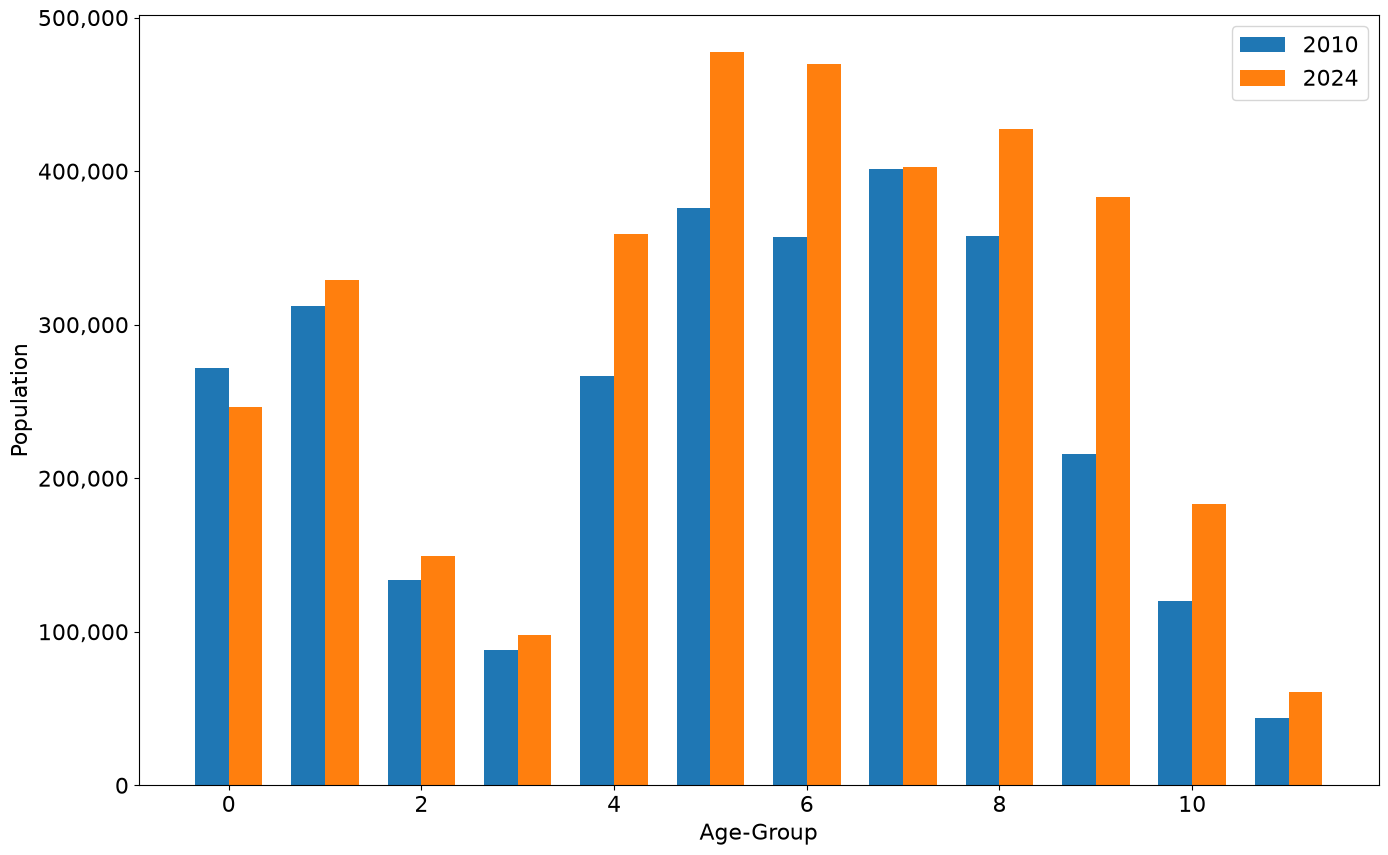

In [37]:
df = pd.DataFrame({'scen_a': county_a[['AGE1', 'AGE2', 'AGE3', 'AGE4', 'AGE5', 'AGE6', 'AGE7', 'AGE8', 'AGE9', 'AGE10', 'AGE11', 'AGE12']].sum(0),
    'scen_b': county_b[['AGE1', 'AGE2', 'AGE3', 'AGE4', 'AGE5', 'AGE6', 'AGE7', 'AGE8', 'AGE9', 'AGE10', 'AGE11', 'AGE12']].sum(0)}).reset_index()
fig = plt.figure(figsize=(16,10))
ax = fig.add_subplot()
bar_width = 0.35
indx = np.arange(len(df['index']))
ax.bar(indx - bar_width/2, df.scen_a, width = bar_width, label = '2010')
ax.bar(indx + bar_width/2, df.scen_b, width = bar_width, label = '2024')
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.legend(loc='upper right', fontsize =16)
ax.set_xlabel('Age-Group', fontsize=16)
ax.set_ylabel('Population', fontsize=16)
plt.tick_params(axis='both', labelsize=16)